In [1]:
# import libraries
import polars as pl
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from tqdm.notebook import tqdm

from scipy import stats
from datetime import date

# polars display
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_width_chars(200)

# plotly renderer
pio.renderers.default = "png"

# data path
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from src.config import RAW_DIR, INTERIM_DIR, PROCESSED_DIR, DOCS_DIR

# warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load data
df = pl.scan_parquet(PROCESSED_DIR / "modelling_base.parquet")

# default column
df = df.with_columns(pl.when(pl.col("loan_status") == pl.lit("paid"))
                        .then(pl.lit(0))
                        .otherwise(pl.lit(1))
                        .alias("default"))

df.head().collect()

loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,loan_status,issue_d,default
i64,i64,f64,i64,f64,f64,cat,cat,i64,cat,f64,cat,cat,str,cat,f64,i64,date,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,cat,i64,i64,cat,i64,f64,f64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,f64,f64,f64,cat,date,i32
12000,12000,12000.0,36,7.97,375.88,"""A""","""A5""",null,"""OWN""",42000.0,"""Source Verified""","""debt_consolidation""","""923xx""","""CA""",27.74,0,1996-06-01,715,719,0,null,80,9,1,11457.0,37.0,16,"""w""",0,null,"""Individual""",0,0.0,30502.0,1,2,1,3,8,19045.0,73.0,2,4,7117.0,53.0,31000.0,1,1,2,7,3389.0,7144.0,53.9,0,0.0,131,255,1,1,0,14,null,8,null,0,2,6,2,2,7,7,9,6,9,0,0,0,3,100.0,0.0,1,0,57180.0,30502.0,15500.0,26180.0,"""paid""",2017-09-01,0
10000,10000,10000.0,36,9.44,320.05,"""B""","""B1""",3,"""MORTGAGE""",55000.0,"""Not Verified""","""debt_consolidation""","""971xx""","""OR""",18.79,0,2005-09-01,695,699,0,68,99,7,1,7188.0,57.5,10,"""w""",0,null,"""Individual""",0,0.0,340607.0,0,4,1,2,10,209187.0,75.0,0,0,6847.0,68.0,12500.0,1,1,1,3,48658.0,3653.0,65.2,0,0.0,144,73,49,10,2,49,null,8,68,0,1,2,1,1,5,2,3,2,7,0,0,0,1,100.0,0.0,1,0,315034.0,216375.0,10500.0,175048.0,"""paid""",2017-09-01,0
8000,8000,8000.0,36,16.02,281.34,"""C""","""C5""",0,"""MORTGAGE""",120000.0,"""Not Verified""","""debt_consolidation""","""136xx""","""NY""",20.36,0,1994-09-01,700,704,1,64,null,8,0,19015.0,92.3,34,"""w""",0,null,"""Joint App""",0,0.0,388595.0,2,3,2,5,6,83572.0,85.0,0,0,0.0,88.0,20600.0,1,24,2,6,55514.0,null,null,0,0.0,137,276,34,6,6,152,null,3,null,0,0,3,1,2,19,4,9,3,8,0,0,0,3,97.1,null,0,0,400558.0,102587.0,0.0,89958.0,"""paid""",2017-09-01,0
12800,12800,12800.0,36,13.59,434.93,"""C""","""C2""",5,"""RENT""",90000.0,"""Not Verified""","""debt_consolidation""","""799xx""","""TX""",22.63,0,1988-12-01,660,664,2,43,null,10,0,12660.0,86.0,23,"""w""",0,94,"""Individual""",0,0.0,93375.0,2,3,2,3,6,80715.0,91.0,1,3,3777.0,86.0,14750.0,0,1,2,6,10375.0,2458.0,86.0,0,0.0,154,345,5,5,0,5,null,5,null,0,6,6,6,6,15,6,8,6,9,null,0,0,3,83.0,83.3,0,0,103040.0,93375.0,14750.0,88290.0,"""paid""",2017-09-01,0
15000,15000,15000.0,36,13.59,509.69,"""C""","""C2""",4,"""MORTGAGE""",180000.0,"""Source Verified""","""medical""","""757xx""","""TX""",38.07,0,1976-12-01,680,684,0,null,null,24,0,107214.0,66.6,50,"""w""",0,null,"""Individual""",0,0.0,682000.0,0,4,0,3,13,190233.0,79.0,0,1,22127.0,68.0,161100.0,2,8,0,5,29652.0,16347.0,86.0,0,0.0,132,489,16,13,4,16,null,13,null,0,10,14,11,16,17,19,29,14,24,0,0,0,0,100.0,72.7,0,0,769704.0,297447.0,116700.0,221207.0,"""paid""",2017-09-01,0


# 5. EDA: Risk Drivers

**Main objective**

Identify and quantify associations between origination-time borrower, credit, and loan characteristics and default risk to establish feature hypotheses for PD modeling.

## 5.1 Feature Screening

In [3]:
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif


def feature_scorecard(
    df: pl.DataFrame,
    target: str = "default",
    n_bins: int = 10,
    min_bin_size: float = 0.01,
    min_non_null: int = 100,
    epsilon: float = 1e-6,
) -> pl.DataFrame:
    """
    Compute a feature scorecard for binary classification.

    Metrics
    -------
    Missingness
        missing_pct     : % of null values

    Predictive Power
        iv              : Information Value (WoE-based)
        auc             : Univariate ROC-AUC (direction-corrected, always >= 0.5)
        mutual_info     : Mutual Information (sklearn, normalized by target entropy)

    Statistical Association
        corr_spearman   : Spearman rank correlation with target
        corr_pb         : Point-biserial correlation (equivalent to Pearson vs binary target)
        cramers_v       : Cramer's V (categorical only; NaN for numeric)
        chi2_pvalue     : Chi-squared p-value (categorical only; NaN for numeric)
        ks_stat         : KS statistic (numeric only; NaN for categorical)
        ks_pvalue       : KS p-value (numeric only; NaN for categorical)

    Summary
        iv_strength     : Verbal label for IV bucket
        n_unique        : Number of unique values
        dtype           : Polars dtype string

    Parameters
    ----------
    df           : Polars DataFrame with features and target
    target       : binary target column name (0/1)
    n_bins       : quantile bins for continuous IV calculation
    min_bin_size : minimum bin fraction for IV (bins smaller than this are dropped)
    min_non_null : minimum non-null rows required to compute any metric
    epsilon      : smoothing constant for WoE/IV to avoid log(0)
    """

    y_full  = df[target].to_numpy().astype(float)
    results = []

    feature_cols = [c for c in df.columns if c != target]

    for col in tqdm(feature_cols, desc="Scoring features"):
        series   = df[col]
        dtype    = str(series.dtype)
        n_rows   = len(series)
        n_null   = series.is_null().sum()
        n_valid  = n_rows - n_null
        missing_pct = round(n_null / n_rows * 100, 4)

        row = {
            "feature":      col,
            "dtype":        dtype,
            "n_unique":     int(series.n_unique()),
            "missing_pct":  missing_pct,
            "iv":           None,
            "auc":          None,
            "mutual_info":  None,
            "corr_spearman": None,
            "corr_pb":      None,
            "cramers_v":    None,
            "chi2_pvalue":  None,
            "ks_stat":      None,
            "ks_pvalue":    None,
        }

        if n_valid < min_non_null:
            results.append(row)
            continue

        # ── Shared setup ─────────────────────────────────────────────
        mask     = series.is_not_null().to_numpy()
        y_valid  = y_full[mask]
        is_numeric = series.dtype.is_numeric()

        # ── Encode feature values for shared use ─────────────────────
        if is_numeric:
            x_raw = series.drop_nulls().to_numpy().astype(float)
        else:
            # Encode categories by within-group default rate
            rate_map = (
                df.select([col, target])
                .filter(pl.col(col).is_not_null())
                .group_by(col)
                .agg(pl.col(target).mean().alias("_rate"))
            )
            x_raw = (
                series.drop_nulls()
                .cast(pl.Utf8)
                .to_frame()
                .join(rate_map.with_columns(pl.col(col).cast(pl.Utf8)), on=col, how="left")
                ["_rate"]
                .to_numpy()
                .astype(float)
            )

        has_variance = len(np.unique(x_raw[~np.isnan(x_raw)])) >= 2
        nan_mask     = ~np.isnan(x_raw)
        x_clean      = x_raw[nan_mask]
        y_clean      = y_valid[nan_mask]

        # ════════════════════════════════════════════════════════════
        # 1. INFORMATION VALUE
        # ════════════════════════════════════════════════════════════
        try:
            data = (
                df.select([col, target])
                .filter(pl.col(target).is_not_null())
            )

            if is_numeric and row["n_unique"] > 2:
                boundaries = sorted(set(
                    float(v)
                    for v in data.select([
                        pl.col(col).quantile(i / n_bins).alias(f"q{i}")
                        for i in range(1, n_bins)
                    ]).row(0)
                    if v is not None
                ))
                if boundaries:
                    data = data.with_columns(
                        pl.col(col).cut(breaks=boundaries).cast(pl.Utf8)
                        .fill_null("MISSING").alias("_bin")
                    )
                else:
                    data = data.with_columns(
                        pl.col(col).cast(pl.Utf8).fill_null("MISSING").alias("_bin")
                    )
            else:
                data = data.with_columns(
                    pl.col(col).cast(pl.Utf8).fill_null("MISSING").alias("_bin")
                )

            grouped = (
                data.group_by("_bin")
                .agg([
                    (pl.col(target) == 0).sum().alias("good"),
                    (pl.col(target) == 1).sum().alias("bad"),
                    pl.len().alias("total"),
                ])
                .filter(pl.col("total") / data.height >= min_bin_size)
            )

            total_good = grouped["good"].sum()
            total_bad  = grouped["bad"].sum()
            n_b        = grouped.height

            if total_good > 0 and total_bad > 0:
                grouped = (
                    grouped
                    .with_columns([
                        ((pl.col("good") + epsilon) / (total_good + epsilon * n_b)).alias("dist_good"),
                        ((pl.col("bad")  + epsilon) / (total_bad  + epsilon * n_b)).alias("dist_bad"),
                    ])
                    .with_columns(
                        (pl.col("dist_good") / pl.col("dist_bad")).log().alias("woe")
                    )
                    .with_columns(
                        ((pl.col("dist_good") - pl.col("dist_bad")) * pl.col("woe")).alias("iv_comp")
                    )
                )
                row["iv"] = round(float(grouped["iv_comp"].sum()), 4)

        except Exception:
            pass

        if not has_variance or len(x_clean) < min_non_null:
            results.append(row)
            continue

        # ════════════════════════════════════════════════════════════
        # 2. UNIVARIATE AUC
        # ════════════════════════════════════════════════════════════
        try:
            auc = roc_auc_score(y_clean, x_clean)
            row["auc"] = round(max(auc, 1 - auc), 4)
        except Exception:
            pass

        # ════════════════════════════════════════════════════════════
        # 3. MUTUAL INFORMATION
        # ════════════════════════════════════════════════════════════
        try:
            mi_raw = mutual_info_classif(
                x_clean.reshape(-1, 1),
                y_clean,
                discrete_features=(not is_numeric or row["n_unique"] <= 2),
                random_state=42,
            )[0]

            # Normalize by target entropy so the scale is [0, 1]
            p    = y_clean.mean()
            h_y  = -p * np.log2(p + 1e-9) - (1 - p) * np.log2(1 - p + 1e-9)
            row["mutual_info"] = round(float(mi_raw / h_y) if h_y > 0 else 0.0, 4)

        except Exception:
            pass

        # ════════════════════════════════════════════════════════════
        # 4. SPEARMAN CORRELATION
        # ════════════════════════════════════════════════════════════
        try:
            rho, _ = stats.spearmanr(x_clean, y_clean)
            row["corr_spearman"] = round(float(rho), 4)
        except Exception:
            pass

        # ════════════════════════════════════════════════════════════
        # 5. POINT-BISERIAL CORRELATION
        # ════════════════════════════════════════════════════════════
        try:
            pb, _ = stats.pointbiserialr(y_clean, x_clean)
            row["corr_pb"] = round(float(pb), 4)
        except Exception:
            pass

        # ════════════════════════════════════════════════════════════
        # 6a. KS STATISTIC  (numeric features)
        # ════════════════════════════════════════════════════════════
        if is_numeric:
            try:
                paid     = x_clean[y_clean == 0]
                defaulted = x_clean[y_clean == 1]
                if len(paid) > 0 and len(defaulted) > 0:
                    ks_res = stats.ks_2samp(paid, defaulted)
                    row["ks_stat"]   = round(float(ks_res.statistic), 4)
                    row["ks_pvalue"] = float(ks_res.pvalue)
            except Exception:
                pass

        # ════════════════════════════════════════════════════════════
        # 6b. CRAMER'S V + CHI-SQUARED  (categorical features)
        # ════════════════════════════════════════════════════════════
        else:
            try:
                ct = (
                    df.select([col, target])
                    .filter(pl.col(col).is_not_null() & pl.col(target).is_not_null())
                    .group_by([col, target])
                    .len()
                    .pivot(index=col, on=target, values="len")
                    .fill_null(0)
                    .drop(col)
                    .to_numpy()
                )
                chi2, p_val, dof, _ = stats.chi2_contingency(ct)
                n    = ct.sum()
                k    = min(ct.shape[0] - 1, ct.shape[1] - 1)
                cv   = float(np.sqrt(chi2 / (n * k))) if n > 0 and k > 0 else 0.0
                row["cramers_v"]   = round(cv, 4)
                row["chi2_pvalue"] = float(p_val)
            except Exception:
                pass

        results.append(row)

    # ── IV strength label ────────────────────────────────────────────
    def iv_label(iv):
        if iv is None:   return None
        if iv < 0.02:    return "Very weak"
        if iv < 0.10:    return "Weak"
        if iv < 0.30:    return "Moderate"
        if iv < 0.50:    return "Strong"
        return "Very strong"

    out = pl.DataFrame(results).with_columns(
        pl.col("iv").map_elements(iv_label, return_dtype=pl.Utf8).alias("iv_strength")
    )

    # Sort by AUC, fall back to IV
    return out.sort(["auc", "iv"], descending=[True, True], nulls_last=True)

In [4]:
# feature_score = feature_scorecard(df.select(pl.exclude(["issue_d", "loan_status"])).collect(), "default")
# feature_score = feature_score.sort(["iv", "auc"], descending=True)

# # add category and description
# data_profile = pl.read_parquet(INTERIM_DIR / "data_profile.parquet")
# feature_score = (feature_score
#     .join(data_profile.select(["feature", "description", "category"]),
#         left_on="feature",
#         right_on="feature",
#         how="left"))

# # save feature score
# feature_score.write_parquet(INTERIM_DIR / "feature_score.parquet")

# load feature score
feature_score = pl.read_parquet(INTERIM_DIR / "feature_score.parquet")


In [5]:
feature_score.head(20)

feature,dtype,n_unique,missing_pct,iv,auc,mutual_info,corr_spearman,corr_pb,cramers_v,chi2_pvalue,ks_stat,ks_pvalue,iv_strength,description,category,description_right,category_right
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str
"""earliest_cr_line""","""Date""",731,0.0,null,0.5398,0.0025,0.0558,0.0612,0.0612,0.0,null,null,null,"""The month the borrower's earliest reported credit line was opened""","""credit_history""","""The month the borrower's earliest reported credit line was opened""","""credit_history"""
"""int_rate""","""Float64""",282,0.0,0.4599,0.6858,0.0558,0.2609,0.2633,null,null,0.2727,0.0,"""Strong""","""Interest Rate on the loan""","""loan_info""","""Interest Rate on the loan""","""loan_info"""
"""grade""","""Categorical""",7,0.0,0.4275,0.6763,0.0468,0.2556,0.2613,0.2613,0.0,null,null,"""Strong""","""LC assigned loan grade""","""credit_profile""","""LC assigned loan grade""","""credit_profile"""
"""sub_grade""","""Categorical""",35,0.0,0.3969,0.6864,0.0499,0.2621,0.2685,0.2685,0.0,null,null,"""Strong""","""LC assigned loan subgrade""","""credit_profile""","""LC assigned loan subgrade""","""credit_profile"""
"""term""","""Int64""",2,0.0,0.1598,0.5877,0.0184,0.1715,0.1715,null,null,0.1755,0.0,"""Moderate""","""The number of payments on the loan. Values are in months and can be either 36 or 60.""","""loan_info""","""The number of payments on the loan. Values are in months and can be either 36 or 60.""","""loan_info"""
"""fico_range_low""","""Int64""",38,0.0,0.1055,0.5874,0.0232,-0.1229,-0.1245,null,null,0.1309,0.0,"""Moderate""","""The lower boundary range the borrower’s FICO at loan origination belongs to.""","""credit_score""","""The lower boundary range the borrower’s FICO at loan origination belongs to.""","""credit_score"""
"""fico_range_high""","""Int64""",38,0.0,0.1055,0.5874,0.0231,-0.1229,-0.1245,null,null,0.1309,0.0,"""Moderate""","""The upper boundary range the borrower’s FICO at loan origination belongs to.""","""credit_score""","""The upper boundary range the borrower’s FICO at loan origination belongs to.""","""credit_score"""
"""installment""","""Float64""",68971,0.0,0.061,0.5654,0.0469,0.0919,0.0798,null,null,0.1062,0.0,"""Weak""","""The monthly payment owed by the borrower if the loan originates.""","""loan_info""","""The monthly payment owed by the borrower if the loan originates.""","""loan_info"""
"""loan_amnt""","""Int64""",1561,0.0,0.0585,0.5674,0.0153,0.0947,0.0864,null,null,0.1043,0.0,"""Weak""","""The listed amount of the loan applied for by the borrower. If at some point in time, the credit depa…","""loan_info""","""The listed amount of the loan applied for by the borrower. If at some point in time, the credit depa…","""loan_info"""


In [6]:
feature_score.filter((pl.col("iv") < 0.001) &
                     (pl.col("mutual_info") < 0.001))

feature,dtype,n_unique,missing_pct,iv,auc,mutual_info,corr_spearman,corr_pb,cramers_v,chi2_pvalue,ks_stat,ks_pvalue,iv_strength,description,category,description_right,category_right
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str
"""total_bal_il""","""Float64""",145850,0.0056,0.0009,0.5004,0.0001,0.0006,-0.0057,null,null,0.0059,0.000025,"""Very weak""","""Total current balance of all installment accounts""","""installment_credit""","""Total current balance of all installment accounts""","""installment_credit"""
"""mths_since_recent_bc_dlq""","""Int64""",169,76.5912,0.0007,0.5105,0.0007,-0.0149,-0.0148,null,null,0.0185,6.0275e-12,"""Very weak""","""Months since most recent bankcard delinquency""","""delinquency""","""Months since most recent bankcard delinquency""","""delinquency"""
"""mths_since_recent_revol_delinq""","""Int64""",171,66.481,0.0007,0.5089,0.0002,-0.0125,-0.0128,null,null,0.0174,4.7927e-15,"""Very weak""","""Months since most recent revolving delinquency.""","""delinquency""","""Months since most recent revolving delinquency.""","""delinquency"""
"""initial_list_status""","""Categorical""",2,0.0,0.0006,0.5053,0.0001,0.0104,0.0104,0.0104,4.8501e-25,null,null,"""Very weak""","""The initial listing status of the loan. Possible values are – W, F""","""loan_info""","""The initial listing status of the loan. Possible values are – W, F""","""loan_info"""
"""tax_liens""","""Int64""",34,0.0,0.0006,0.5021,0.0007,0.0097,0.0071,null,null,0.0042,0.006533,"""Very weak""","""Number of tax liens""","""public_record""","""Number of tax liens""","""public_record"""
"""chargeoff_within_12_mths""","""Int64""",10,0.0,0.0,0.5007,0.0003,0.0066,0.0059,null,null,0.0014,0.889905,"""Very weak""","""Number of charge-offs within 12 months""","""delinquency""","""Number of charge-offs within 12 months""","""delinquency"""
"""acc_now_delinq""","""Int64""",5,0.0,0.0,0.5001,0.0002,-0.0007,-0.0007,null,null,0.0001,1.0,"""Very weak""","""The number of accounts on which the borrower is now delinquent.""","""delinquency""","""The number of accounts on which the borrower is now delinquent.""","""delinquency"""
"""delinq_amnt""","""Float64""",1656,0.0,0.0,0.5001,0.0002,0.0015,0.003,null,null,0.0005,1.0,"""Very weak""","""The past-due amount owed for the accounts on which the borrower is now delinquent.""","""delinquency""","""The past-due amount owed for the accounts on which the borrower is now delinquent.""","""delinquency"""
"""num_tl_30dpd""","""Int64""",5,0.0,0.0,0.5001,0.0001,-0.0012,-0.0011,null,null,0.0001,1.0,"""Very weak""","""Number of accounts currently 30 days past due (updated in past 2 months)""","""delinquency""","""Number of accounts currently 30 days past due (updated in past 2 months)""","""delinquency"""


**Top Signals**
- `int_rate`, `grade`, `sub_grade` are the strongest predictors (IV 0.40–0.46, AUC 0.68–0.69, KS 0.27), but all three are LC-assigned risk proxies that internally encode FICO, so they're correlated by construction, not independent signals
- `term` is the strongest genuinely independent feature (IV 0.16, AUC 0.59), 60-month loans default materially more than 36-month
- `fico_range_low/high` are surprisingly weak as raw features (IV 0.11, AUC 0.59) compared to the grade/rate proxies built on top of them

**Moderate Signals (IV 0.02–0.10)**
- Wealth/capacity proxies cluster here: `bc_open_to_buy`, `tot_hi_cred_lim`, `mort_acc`, `avg_cur_bal`, all negative Spearman, meaning more assets = lower default risk
- `dti` and `verification_status` land here, both confirmed findings from domain knowledge
- `open_rv_24m` and `acc_open_past_24mths` capture recent credit-seeking behavior, both positively correlated with default

**Metric Disagreements Worth Investigating**
- `pct_tl_nvr_dlq` has very low IV (0.0017) and AUC (0.51) but the highest mutual info in the dataset (0.0613), suggests a strong non-linear relationship that WoE binning and rank correlation are completely missing; worth transforming or tree-splitting before dismissing
- `installment` and `open_il_12m/24m` similarly show high mutual info relative to their IV/AUC, suggesting non-monotonic effects
- `earliest_cr_line` has no IV computed (Date type bypassed binning) but non-trivial AUC 0.54, should be converted to credit age in months and rescored

**Missingness Flags**
- `mths_since_last_record` (82%), `mths_since_recent_bc_dlq` (77%), `mths_since_last_major_derog` (73%), `mths_since_recent_revol_delinq` (66%), all extremely sparse; their informative-missing flags likely carry more signal than the values themselves
- `il_util` at 14% missing and `mths_since_recent_inq` at 10% are borderline, keep but flag
- `emp_length` at 40% missing is problematic; the missing indicator is probably the useful feature, not the value

**Drop Candidates**
- `acc_now_delinq`, `delinq_amnt`, `num_tl_30dpd`, AUC exactly 0.50, KS ~0, IV 0.00; zero predictive signal by every metric
- `chargeoff_within_12_mths`, `tax_liens`, `total_bal_il`, near-zero across all metrics
- `funded_amnt` and `funded_amnt_inv` are duplicates of `loan_amnt` (identical IV, AUC, KS, Spearman), drop both

**Recommended Feature Tiers for Modeling**

| Tier | Features |
|---|---|
| Keep (strong) | `int_rate`, `term`, `fico_range_low`, `grade` |
| Keep (moderate) | `dti`, `mort_acc`, `bc_open_to_buy`, `tot_hi_cred_lim`, `verification_status`, `open_rv_24m`, `avg_cur_bal`, `annual_inc` |
| Investigate further | `pct_tl_nvr_dlq`, `installment`, `earliest_cr_line` (recode), `mths_since_*` (use flags) |
| Drop | `funded_amnt`, `funded_amnt_inv`, `acc_now_delinq`, `delinq_amnt`, `num_tl_30dpd`, `chargeoff_within_12_mths` |

In [7]:
DROP_COL = ["funded_amnt", "funded_amnt_inv", "acc_now_delinq", "delinq_amnt", "num_tl_30dpd", 
            "chargeoff_within_12_mths", "tax_liens", "total_ball_il", ""]

In [8]:
mths_since_cols = df.select(pl.col("^mths_since_.*$")).columns

df_eng = (df
            .with_columns([
                pl.col(col).is_null().cast(pl.Int8).alias(f"{col}_null")
                for col in mths_since_cols
            ])
            .with_columns([
                pl.col(col).fill_null(0)
                for col in mths_since_cols
            ])
            .with_columns(
                ((pl.col("issue_d") - pl.col("earliest_cr_line")).dt.total_days() // 30)
                .alias("cr_age_mths"))

            .select(pl.col("^mths_since_.*$"), pl.col("cr_age_mths"), pl.col("default"))

            .collect())

In [9]:
feature_score_eng = feature_scorecard(df_eng, "default")
feature_score_eng = feature_score_eng.sort(["iv", "auc"], descending=True)

Scoring features:   0%|          | 0/17 [00:00<?, ?it/s]

In [10]:
feature_score_eng

feature,dtype,n_unique,missing_pct,iv,auc,mutual_info,corr_spearman,corr_pb,cramers_v,chi2_pvalue,ks_stat,ks_pvalue,iv_strength
str,str,i64,f64,f64,f64,f64,f64,f64,null,null,f64,f64,str
"""mths_since_recent_bc""","""Int64""",486,0.0,0.0206,0.5386,0.0047,-0.0543,-0.0466,null,null,0.0574,0.0,"""Weak"""
"""mths_since_recent_inq""","""Int64""",26,0.0,0.0139,0.5244,0.0088,-0.0345,-0.0372,null,null,0.0444,2.3977e-280,"""Very weak"""
"""cr_age_mths""","""Int64""",732,0.0,0.0138,0.5329,0.0029,-0.0463,-0.0384,null,null,0.0522,0.0,"""Very weak"""
"""mths_since_rcnt_il""","""Int64""",381,0.0,0.0112,0.5293,0.0046,-0.0411,-0.0204,null,null,0.0457,1.5129e-296,"""Very weak"""
"""mths_since_recent_inq_null""","""Int8""",2,0.0,0.0082,0.5131,0.0009,-0.0354,-0.0354,null,null,0.0263,1.4793e-98,"""Very weak"""
"""mths_since_last_major_derog""","""Int64""",174,0.0,0.0055,0.5142,0.001,0.0254,0.0184,null,null,0.0308,2.0674e-135,"""Very weak"""
"""mths_since_last_record""","""Int64""",127,0.0,0.0051,0.5139,0.0003,0.0294,0.0286,null,null,0.0272,8.2596e-106,"""Very weak"""
"""mths_since_last_record_null""","""Int8""",2,0.0,0.005,0.5136,0.0006,-0.029,-0.029,null,null,0.0272,7.7801e-106,"""Very weak"""
"""mths_since_last_major_derog_null""","""Int8""",2,0.0,0.0047,0.5154,0.0005,-0.0282,-0.0282,null,null,0.0309,1.0258e-135,"""Very weak"""


**Features Worth Keeping**
- `mths_since_recent_bc` is the strongest in this group (IV 0.021, AUC 0.539, KS 0.057) and crosses the weak signal threshold, meaning recent bankcard activity timing carries some real default signal
- `mths_since_recent_inq` and `cr_age_mths` are close behind with AUC around 0.524-0.533, both statistically significant with KS p-value near zero, so they contribute something even if modest
- `mths_since_rcnt_il` shows similar modest signal (AUC 0.529, KS 0.046) and is worth retaining

**Null Flags: Mixed Results**
- `mths_since_recent_inq_null` (AUC 0.513, IV 0.008) is the only null flag with meaningful signal, meaning whether a borrower has had a recent inquiry at all is informative beyond the timing itself
- `mths_since_last_record_null` and `mths_since_last_major_derog_null` carry weak but non-trivial signal (AUC ~0.514-0.515), consistent with the idea that having no public record or major derogatory mark is a mild protective signal
- The remaining null flags (`mths_since_recent_bc_null`, `mths_since_recent_bc_dlq_null`, `mths_since_recent_revol_delinq_null`) are essentially noise with AUC at or below 0.504 and IV near zero; drop them

**Derogatory and Delinquency Features are Weak**
- `mths_since_last_major_derog`, `mths_since_last_record`, `mths_since_last_delinq` all show very low signal (AUC 0.505-0.514, IV under 0.006) despite being intuitively important risk indicators
- This is likely because the null-fill with 0 compressed the distribution, and the actual timing after the event has little discriminative power once you already know the event occurred; the null flag captures most of the available signal
- `mths_since_recent_bc_dlq` and `mths_since_recent_revol_delinq` are near-zero across every metric and should be dropped

**Overall Assessment**

| Decision | Features |
|---|---|
| Keep (value) | `mths_since_recent_bc`, `mths_since_recent_inq`, `mths_since_rcnt_il`, `cr_age_mths` |
| Keep (null flag only) | `mths_since_recent_inq_null`, `mths_since_last_record_null`, `mths_since_last_major_derog_null` |
| Drop | `mths_since_recent_bc_dlq`, `mths_since_recent_revol_delinq`, all remaining null flags |

The core pattern here is that recency of positive credit activity (bankcard usage, inquiries, installment accounts) carries more signal than recency of negative events, and for the derogatory features the existence flag does more work than the timing value.

In [11]:
KEEP_COL_ENG = ["mths_since_recent_bc", "mths_since_recent_inq", "mths_since_rcnt_il", "cr_age_mths"
                "mths_since_recent_inq_null", "mths_since_last_record_null", "mths_since_last_major_derog_null"]

## 5.2 Top Feature Based Feature Screening

The feature scorecard covers three metric groups: predictive power (IV, AUC), statistical association (Spearman, KS), and non-linear detection (Mutual Information). Rather than taking all features forward, selection is guided by two principles: business relevance as a baseline underwriting variable, and statistical contribution of independent signal beyond what other features already capture.

### Why Not All Top Features

Several high-ranking features are excluded despite strong scores:

- `grade` and `sub_grade` (credit_profile) are redundant with `int_rate` since all three encode the same LC internal risk score. Only `int_rate` is kept as it carries the raw continuous signal.
- `funded_amnt` and `funded_amnt_inv` (loan_info) are exact duplicates of `loan_amnt` with identical scores across every metric.
- `installment` (loan_info) is a mathematical function of `loan_amnt`, `int_rate`, and `term` combined, so it adds no independent information once those three are included.
- `pct_tl_nvr_dlq` (credit_profile) shows an interesting gap between MI and IV/AUC, suggesting a non-linear pattern, but the overall signal is too weak to justify EDA at this stage. It will be revisited during modeling.
- `open_il_12m` and `open_il_24m` (installment_credit) overlap heavily with `open_rv_24m` (revolving_credit), which showed cleaner signal. Revolving account activity is also more interpretable than installment account opening for consumer credit risk.
- `inq_last_6mths` (credit_inquiry) is captured indirectly through `mths_since_recent_inq`, so keeping both would be redundant.

### Selected Features and Justification

The final 12 features cover all major credit risk dimensions without redundancy.

**Loan Info**
- `int_rate` : strongest independent signal overall (IV 0.46, AUC 0.69, KS 0.27); directly reflects LC risk pricing for each borrower
- `term` : strongest non-LC-proxy feature (IV 0.16, AUC 0.59); 60-month loans default materially more than 36-month loans
- `loan_amnt` : baseline loan size; higher requested amount correlates with default and represents borrower exposure at origination

**Borrower Profile**
- `annual_inc` : self-reported income is the fundamental repayment capacity signal; required for any borrower profile analysis
- `verification_status` : captures LC internal risk flagging behavior; the counterintuitive direction where verified loans default more is itself a finding worth documenting in EDA

**Credit Score**
- `fico_range_low` : primary bureau credit score representing creditworthiness at origination; lower boundary is the standard convention used in lending

**Credit Profile**
- `dti` : debt-to-income ratio is a core underwriting variable present in every credit risk framework including the CFPB qualified mortgage standard
- `mort_acc` : number of mortgage accounts is the best available asset ownership proxy; negative Spearman confirms a protective effect on default risk
- `cr_age_mths` : engineered from `earliest_cr_line` (credit_history); length of credit history is a standard underwriting input and represents borrower credit maturity

**Revolving Credit**
- `open_rv_24m` : number of revolving trades opened in past 24 months is the cleanest recent credit activity proxy (IV 0.044); captures credit-seeking behavior over a stable window
- `mths_since_recent_bc` : months since most recent bankcard account opened; strongest signal in the recency group (IV 0.021, AUC 0.539)

**Credit Inquiry**
- `mths_since_recent_inq` : months since most recent inquiry; moderate signal and its null flag adds independent information about whether a recent inquiry exists at all, which itself is informative

In [12]:
selected_features = [
    
    # Loan Info
    "int_rate",
    "term",
    "loan_amnt",
    
    # Borrower Profile
    "annual_inc",
    "verification_status",
    
    # Credit Score
    "fico_range_low",
    
    # Credit Profile
    "dti",
    "mort_acc",
    "cr_age_mths",
    
    # Revolving Credit
    "open_rv_24m",
    "mths_since_recent_bc",
    
    # Credit Inquiry
    "mths_since_recent_inq",
    
    # Target
    "default",
    "loan_status"
]

In [13]:
df_eda = (df
            .with_columns([
                pl.col(col).is_null().cast(pl.Int8).alias(f"{col}_null")
                for col in mths_since_cols
            ])
            .with_columns([
                pl.col(col).fill_null(0)
                for col in mths_since_cols
            ])
            .with_columns(
                ((pl.col("issue_d") - pl.col("earliest_cr_line")).dt.total_days() // 30)
                .alias("cr_age_mths"))

            .select(selected_features))

In [14]:
df_eda.head(10).collect()

int_rate,term,loan_amnt,annual_inc,verification_status,fico_range_low,dti,mort_acc,cr_age_mths,open_rv_24m,mths_since_recent_bc,mths_since_recent_inq,default,loan_status
f64,i64,i64,f64,cat,i64,f64,i64,i64,i64,i64,i64,i32,cat
7.97,36,12000,42000.0,"""Source Verified""",715,27.74,0,258,4,14,8,0,"""paid"""
9.44,36,10000,55000.0,"""Not Verified""",695,18.79,2,146,0,49,8,0,"""paid"""
16.02,36,8000,120000.0,"""Not Verified""",700,20.36,6,280,0,152,3,0,"""paid"""
13.59,36,12800,90000.0,"""Not Verified""",660,22.63,0,350,3,5,5,0,"""paid"""
13.59,36,15000,180000.0,"""Source Verified""",680,38.07,4,496,1,16,13,0,"""paid"""
7.97,60,40000,200000.0,"""Verified""",760,14.37,6,159,1,28,1,1,"""default"""
16.02,60,18000,125000.0,"""Not Verified""",675,9.53,0,133,6,5,5,0,"""paid"""
23.88,36,2000,24000.0,"""Verified""",660,42.2,1,192,2,40,4,0,"""paid"""
17.09,60,16000,60000.0,"""Source Verified""",660,24.72,0,171,6,13,0,1,"""default"""


## 5.3 Risk Driver Analysis

In [15]:
def plot_cat_dist(df:pl.LazyFrame, col:str, col_name:str=None):
    if col_name==None:
        col_name = col.replace("_"," ").capitalize()

    # data
    data_dist =  (
        df
        .group_by(col)
        .len(name="count")

        .with_columns((pl.col("count") / pl.col("count").sum() * 100.0)
            .round(2)
            .alias("percentage"))

        .sort(col)
        .with_columns(pl.col(col).cast(pl.Utf8))

        .collect())

    # plot
    fig = px.bar(
        data_dist.to_pandas(),
        x=col,
        y="count",
        text="percentage",
        color=col,
        title=f"Loan {col_name} Distribution",
        labels={
            col: f"Loan {col_name}",
            "count": "Number of Loans",
            "percentage": "Percentage"})

    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
    fig.update_layout(template="plotly_white")

    return data_dist, fig


def plot_cat_default(df:pl.LazyFrame, col:str, target:str='loan_status', col_name:str=None, target_name:str=None):
    if col_name==None:
        col_name = col.replace("_"," ").capitalize()

    if target_name==None:
        target_name = target.replace("_"," ").capitalize()
    
    # data
    data_dist = (
        df
        .group_by([col, target])
        .len(name="count")
        .with_columns(
            (pl.col("count") / pl.col("count").sum().over(col) * 100)
            .round(2)
            .alias(f"pct_within_{col}"),
            pl.col(col).cast(pl.Utf8)
        )
        .sort([col, target])
        .collect())

    # plot
    fig = px.bar(
        data_dist.to_pandas(),
        x=col,
        y="count",
        color=target,
        text=f"pct_within_{col}",
        barmode="group",
        color_discrete_map={"paid": "#1E8A5F", "default": "#C23B3B"},
        title=f"Loan {col_name} Distribution by Outcome",
        labels={col: f"Loan {col_name}", "count": "Number of Loans"},
        category_orders={col: data_dist.select(pl.col(col)).unique()[col].to_list(), target: ["paid", "default"]},
    )
    fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")
    fig.update_layout(template="plotly_white", xaxis=dict(type="category"), legend_title=target_name)

    return data_dist, fig

In [16]:
def plot_num_dist(df:pl.LazyFrame, col:str, col_name:str=None):
    if col_name==None:
        col_name = col.replace("_"," ").capitalize()

    fig = px.histogram(
            df.select(col).collect().to_pandas(),
            x=col,
            nbins=50,
            marginal="box",
            title=f"{col_name} Distribution",
            labels={col: col_name})

    fig.update_layout(template="plotly_white")

    return fig

def plot_num_default(df:pl.LazyFrame, col:str, target:str='loan_status', col_name:str=None, target_name:str=None):
    if col_name==None:
        col_name = col.replace("_"," ").capitalize()

    if target_name==None:
        target_name = target.replace("_"," ").capitalize()

    fig = px.histogram(
                df.select(col, target).collect().to_pandas(),
                x=col,
                color=target,
                nbins=50,
                marginal="box",
                barmode="overlay",
                opacity=0.5,
                histnorm="probability density",
                color_discrete_map={"paid": "#1E8A5F", "default": "#C23B3B"},
                title=f"{col_name} Distribution by {target_name}",
                labels={col: col_name, target: target_name},
                category_orders={target: ["paid", "default"]},)

    fig.update_layout(template="plotly_white", legend_title=target_name)

    return fig

### 5.3.1 Interest Rate

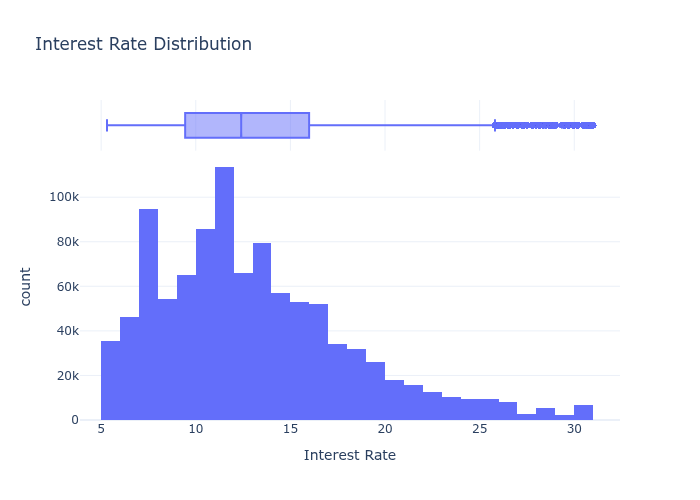

In [17]:
fig = plot_num_dist(df_eda, "int_rate", "Interest Rate")
fig.show()

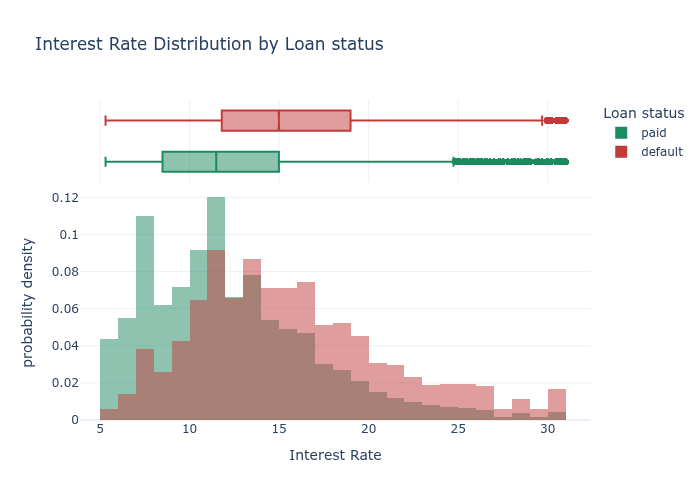

In [18]:
fig = plot_num_default(df_eda, "int_rate", col_name="Interest Rate")
fig.show()

### 5.3.2 Term

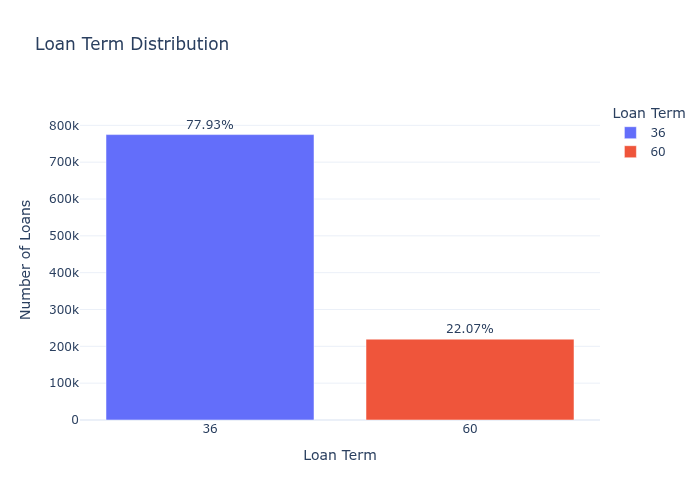

In [19]:
_, fig = plot_cat_dist(df_eda, "term")
fig.show()

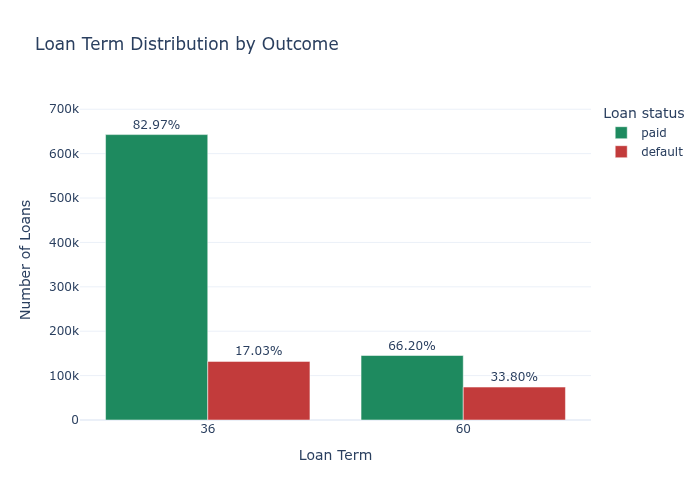

In [20]:
_, fig = plot_cat_default(df_eda, "term")
fig.show()

### 5.3.3 Loan Amount

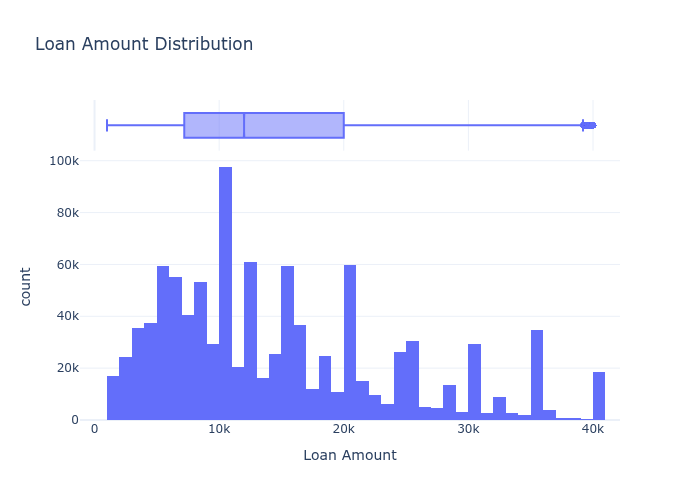

In [21]:
fig = plot_num_dist(df_eda, "loan_amnt", "Loan Amount")
fig.show()

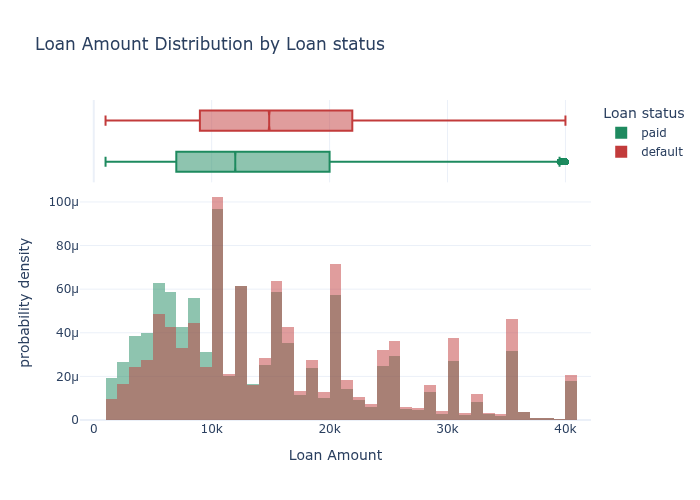

In [22]:
fig = plot_num_default(df_eda, "loan_amnt", col_name="Loan Amount")
fig.show()

### 5.3.4 Annual Income

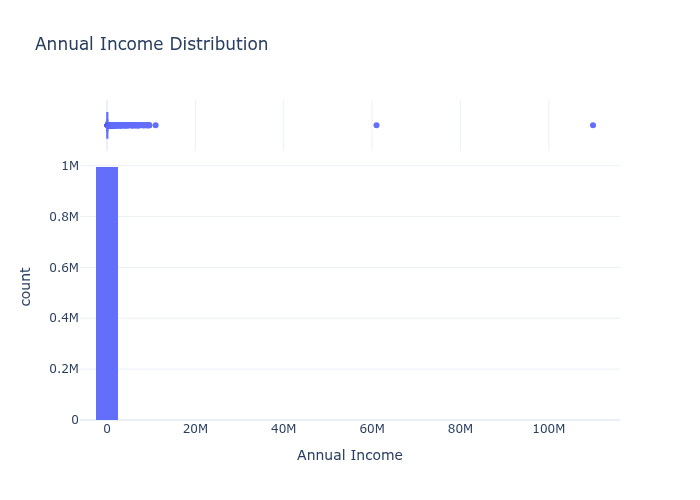

In [23]:
fig = plot_num_dist(df_eda, "annual_inc", "Annual Income")
fig.show()

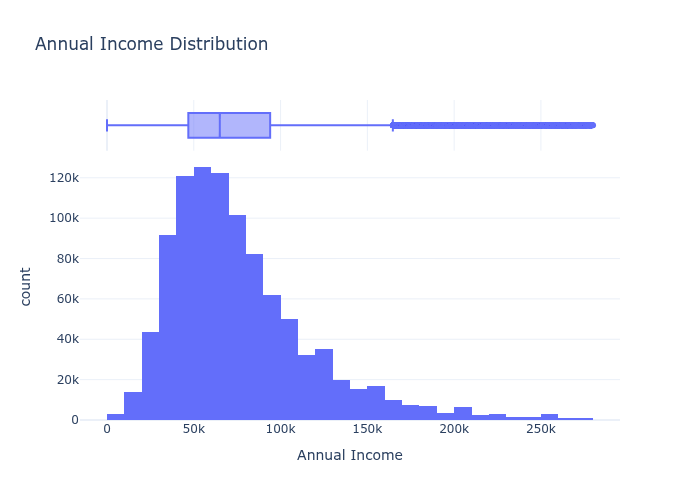

In [24]:
# filter by percentile, because have outlier
col = "annual_inc"
temp_df = df_eda.filter(pl.col(col) < pl.col(col).quantile(0.99))

fig = plot_num_dist(temp_df, col, "Annual Income")
fig.show()

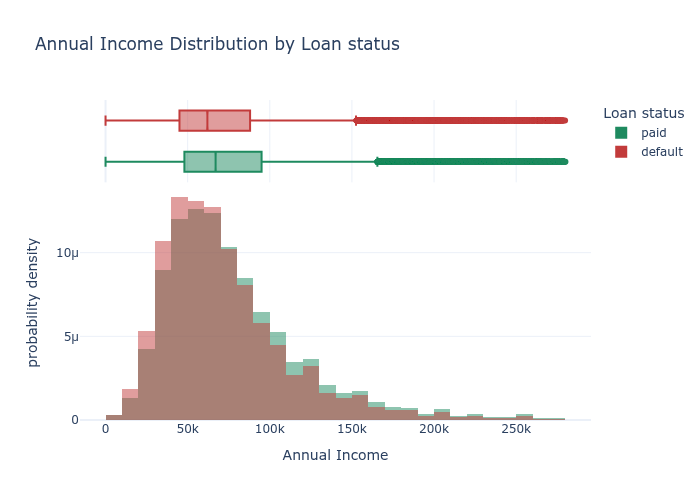

In [25]:
fig = plot_num_default(temp_df, col, col_name="Annual Income")
fig.show()

### 5.3.5 Verification Status

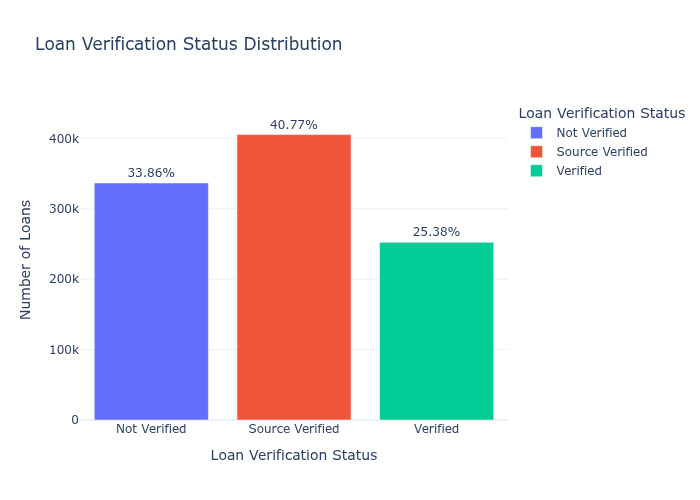

In [26]:
_, fig = plot_cat_dist(df_eda, "verification_status", "Verification Status")
fig.show()

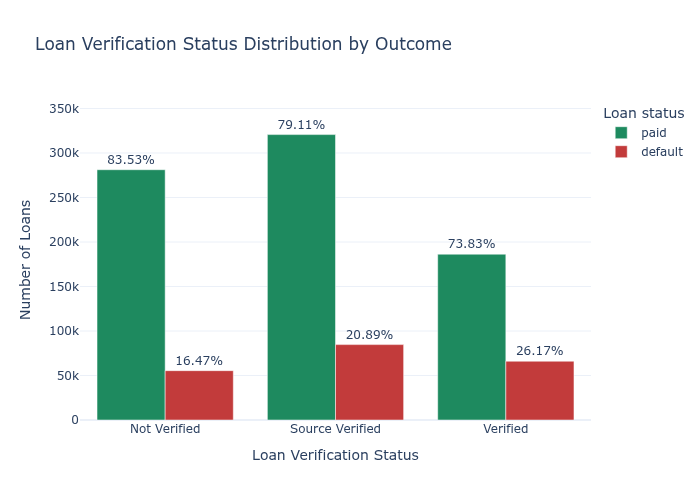

In [27]:
_, fig = plot_cat_default(df_eda,"verification_status", col_name="Verification Status")
fig.show()

### 5.3.6 FICO

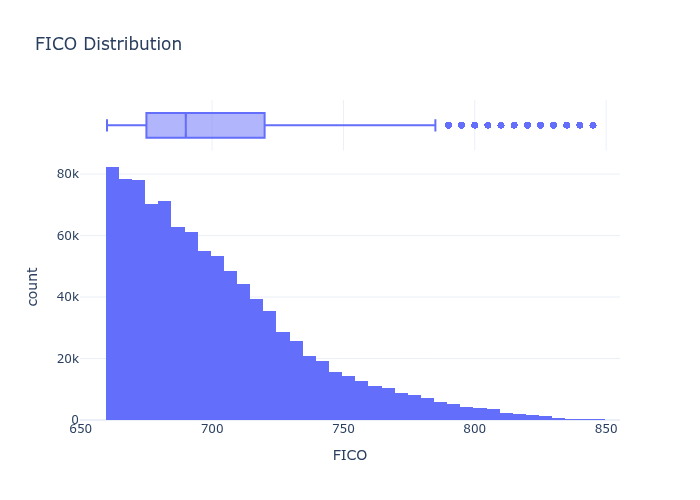

In [28]:
fig = plot_num_dist(df_eda, "fico_range_low", "FICO")
fig.show()

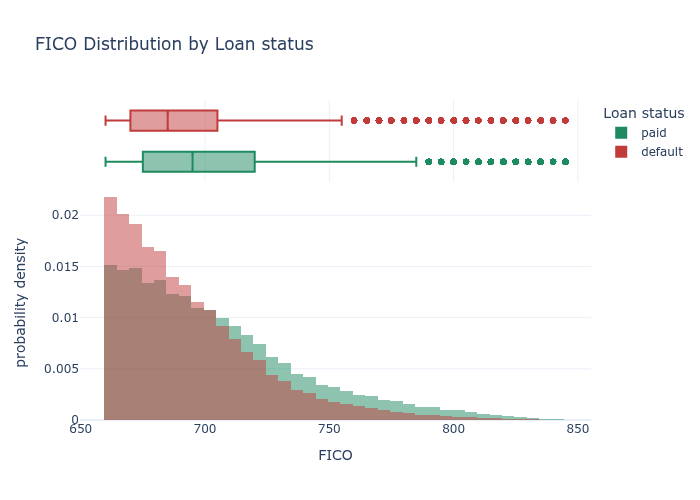

In [29]:
fig = plot_num_default(df_eda, "fico_range_low", col_name="FICO")
fig.show()

### 5.3.7 DTI

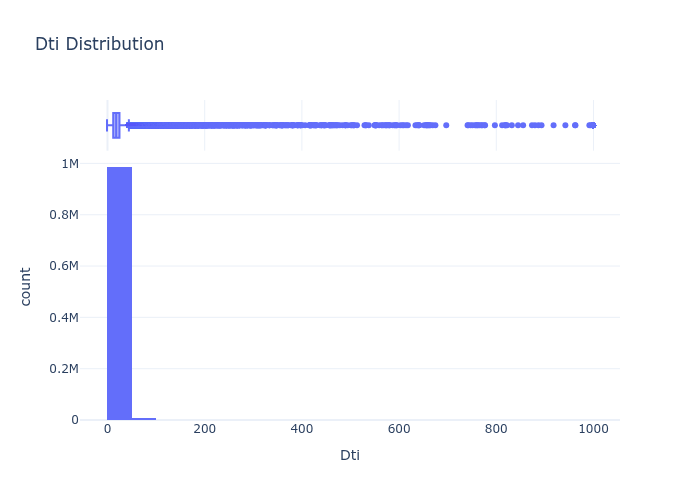

In [32]:
fig = plot_num_dist(df_eda, "dti",)
fig.show()

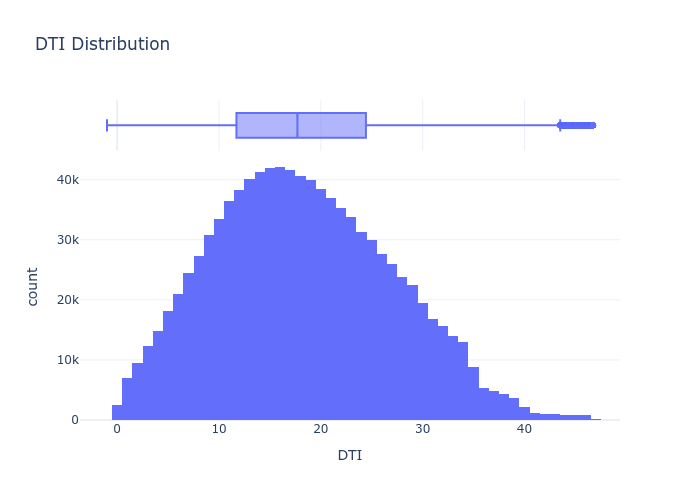

In [36]:
# filter by percentile, because have outlier
col = "dti"
temp_df = df_eda.filter(pl.col(col) < pl.col(col).quantile(0.99))

fig = plot_num_dist(temp_df, col, "DTI")
fig.show()

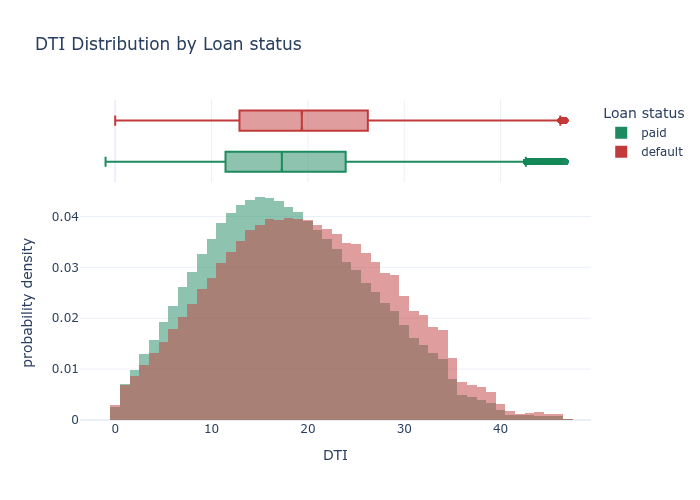

In [38]:
fig = plot_num_default(temp_df, "dti", col_name="DTI")
fig.show()

### 5.3.8 Mortgage Account

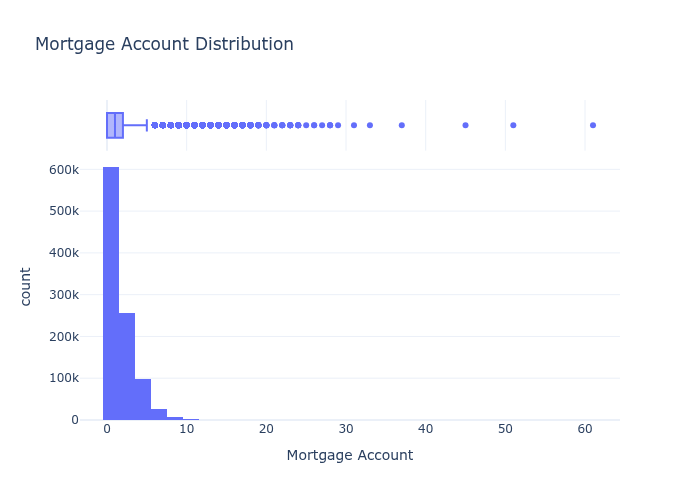

In [40]:
fig = plot_num_dist(df_eda, "mort_acc", "Mortgage Account")
fig.show()

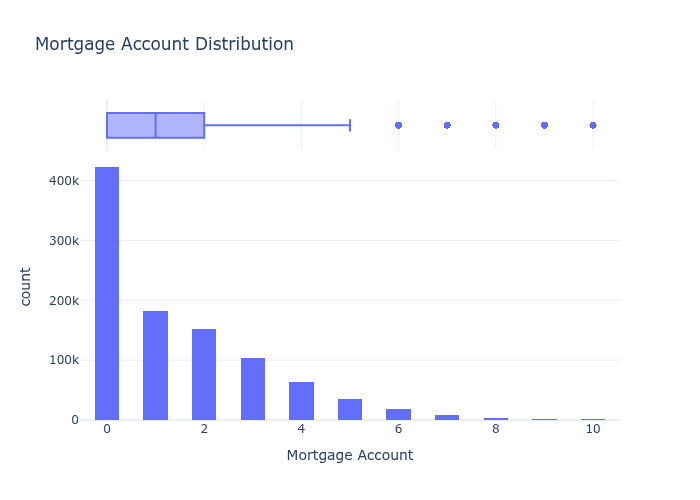

In [42]:
# filter by percentile, because have outlier
col = "mort_acc"
temp_df = df_eda.filter(pl.col(col) < pl.col(col).quantile(0.999))

fig = plot_num_dist(temp_df, col, "Mortgage Account")
fig.show()

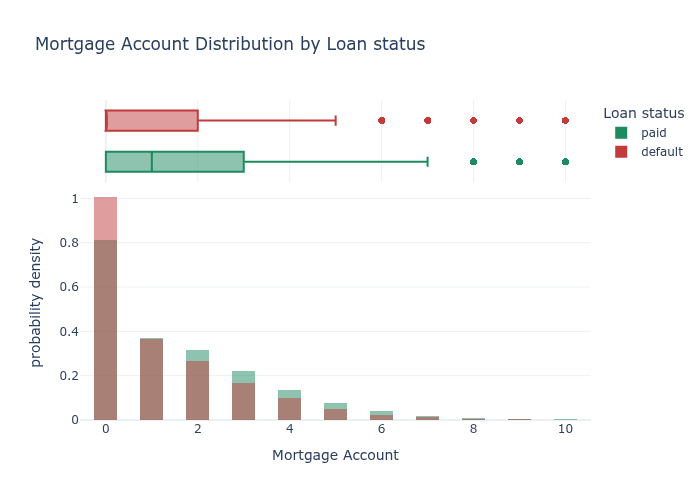

In [43]:
fig = plot_num_default(temp_df, "mort_acc", col_name="Mortgage Account")
fig.show()

### 5.3.9 Credit Age Months

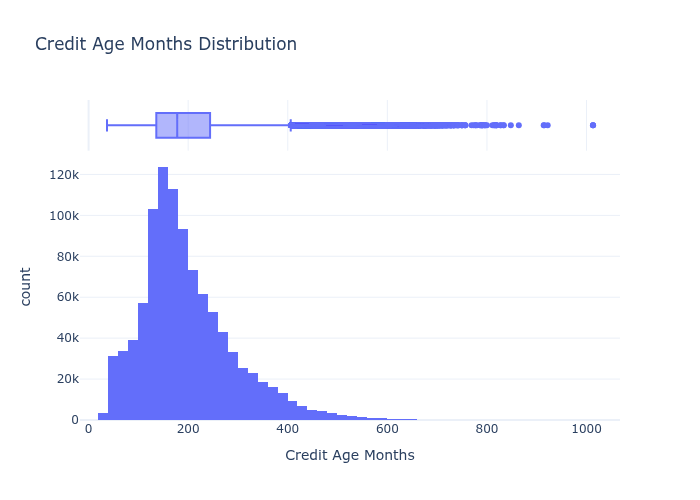

In [44]:
fig = plot_num_dist(df_eda, "cr_age_mths", "Credit Age Months")
fig.show()

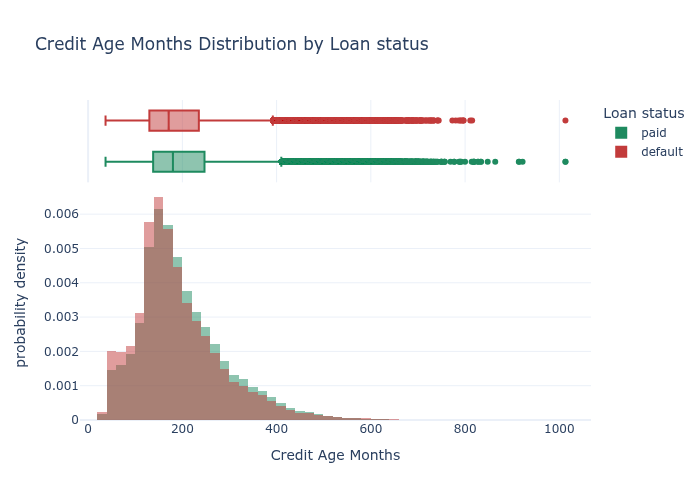

In [45]:
fig = plot_num_default(df_eda, "cr_age_mths", col_name="Credit Age Months")
fig.show()

### 5.3.10 Revolving Trades Opened in Past 24 Months

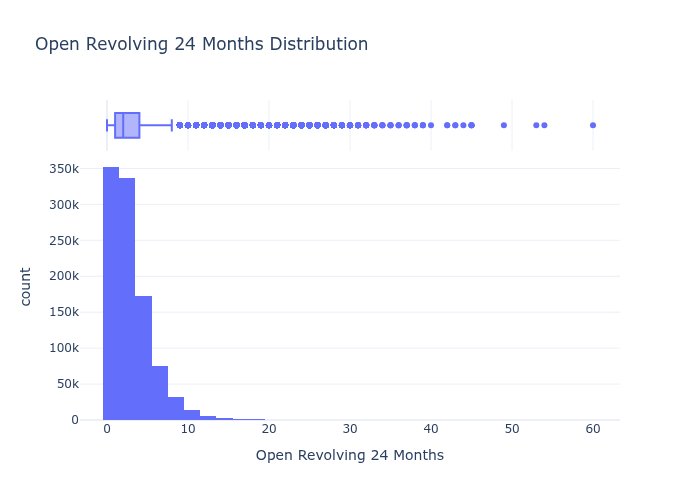

In [46]:
fig = plot_num_dist(df_eda, "open_rv_24m", "Open Revolving 24 Months")
fig.show()

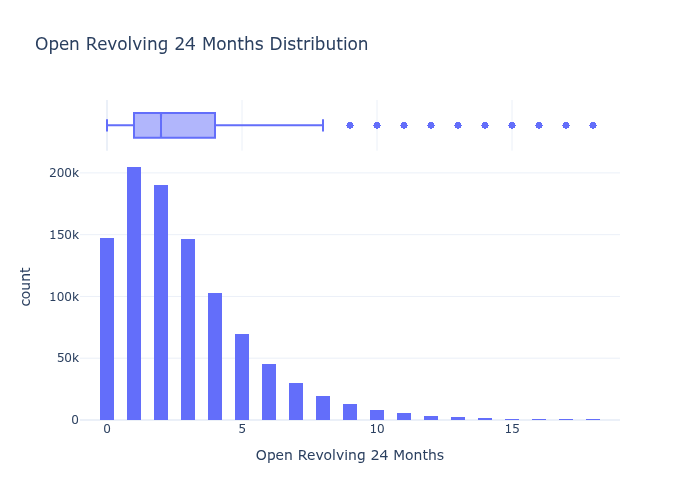

In [47]:
# filter by percentile, because have outlier
col = "open_rv_24m"
temp_df = df_eda.filter(pl.col(col) < pl.col(col).quantile(0.999))

fig = plot_num_dist(temp_df, col, "Open Revolving 24 Months")
fig.show()

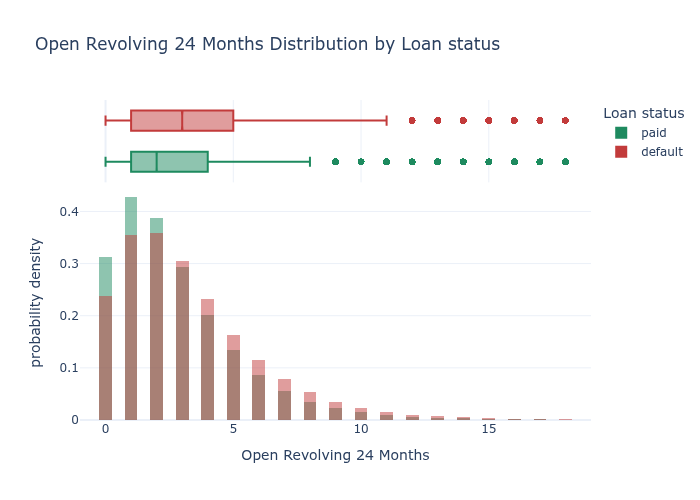

In [48]:
fig = plot_num_default(temp_df, col, col_name="Open Revolving 24 Months")
fig.show()

### 5.3.11 Months Since Recent Bankcard

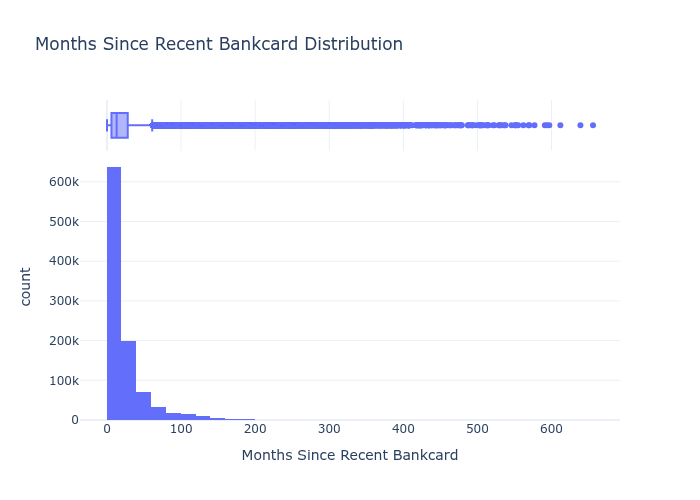

In [49]:
fig = plot_num_dist(df_eda, "mths_since_recent_bc", "Months Since Recent Bankcard")
fig.show()

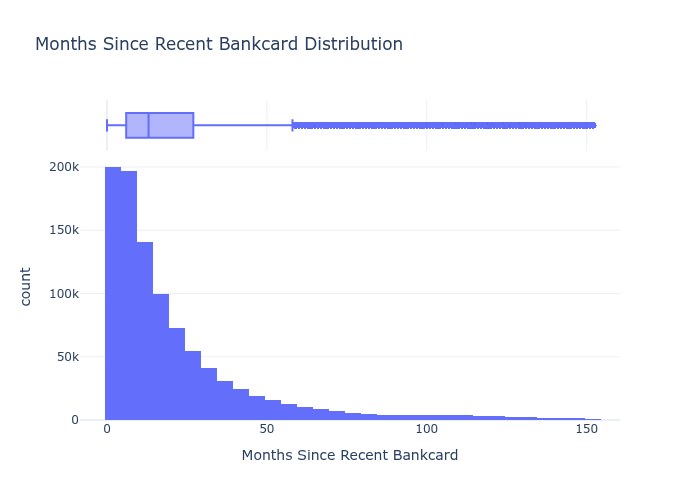

In [52]:
# filter by percentile, because have outlier
col = "mths_since_recent_bc"
temp_df = df_eda.filter(pl.col(col) < pl.col(col).quantile(0.99))

fig = plot_num_dist(temp_df, col, "Months Since Recent Bankcard")
fig.show()

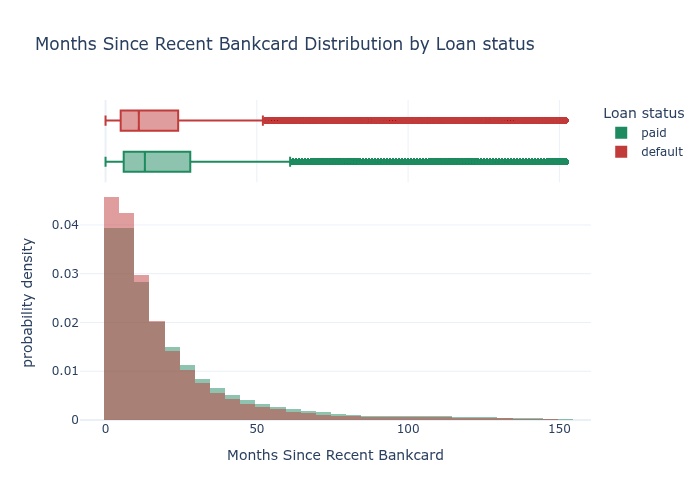

In [53]:
fig = plot_num_default(temp_df, col, col_name="Months Since Recent Bankcard")
fig.show()

### 5.3.12 Months Since Recent Inquiry

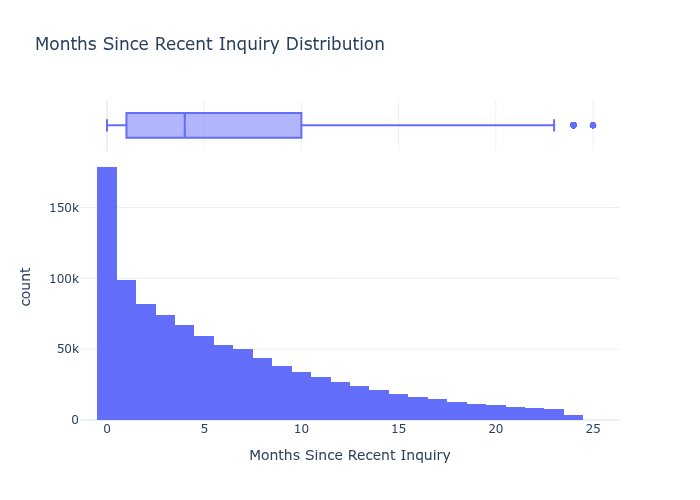

In [54]:
fig = plot_num_dist(df_eda, "mths_since_recent_inq", "Months Since Recent Inquiry")
fig.show()

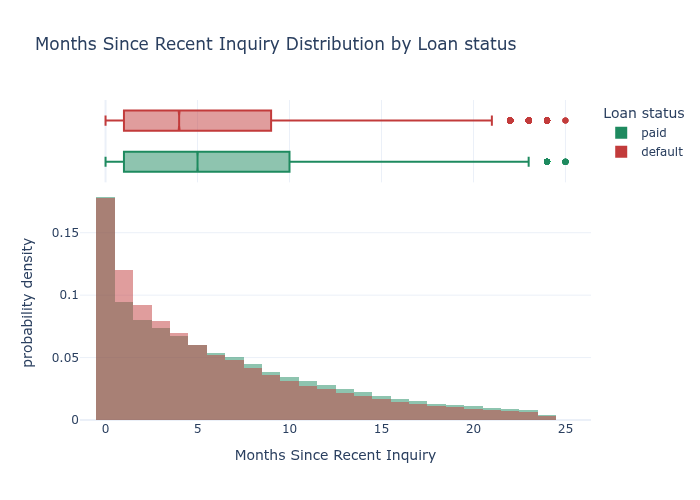

In [55]:
fig = plot_num_default(temp_df, "mths_since_recent_inq", col_name="Months Since Recent Inquiry")
fig.show()